# Install and load required packages

This benchmark compares the relative computation time to estimate a preference space mixed logit model using the following R packages:

- {logitr}
- {mixl}
- {mlogit}
- {gmnl}
- {apollo}

Benchmarks will *always* vary for every run of a benchmarking code, even when run on the same machine due to variations in background processes. Thus, if you run this code yourself on a different machine, your results may vary, though the overall order and trends in terms of each package's relative speed should be similar to those from this notebook.

To get started, install the required packages (only need to do this once):

In [ ]:
# Install packages for creating figures
install.packages(c("tidyverse", "cowplot", "ggrepel"))

# Install packages for benchmarking
install.packages(c("mlogit", "gmnl", "apollo", "mixl", "fastDummies"))

# Installed latest dev version of logitr
install.packages("remotes")
remotes::install_github("jhelvy/logitr")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘Rcpp’


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘SparseM’, ‘MatrixModels’, ‘mcmc’, ‘quantreg’, ‘rbibutils’, ‘miscTools’, ‘expm’, ‘rngWELL’, ‘MCMCpack’, ‘dfidx’, ‘Formula’, ‘zoo’, ‘lmtest’, ‘statmod’, ‘Rdpack’, ‘maxLik’, ‘plotrix’, ‘msm’, ‘truncnorm’, ‘mnormt’, ‘mvtnorm’, ‘randtoolbox’, ‘numDeriv’, ‘Deriv’, ‘matrixStats’, ‘RSGHB’, ‘coda’, ‘RcppArmadillo’, ‘RcppEigen’, ‘sandwich’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




vctrs    (0.4.1 -> 0.4.2) [CRAN]
tibble   (3.1.7 -> 3.1.8) [CRAN]
jsonlite (1.8.0 -> 1.8.2) [CRAN]
crayon   (1.5.1 -> 1.5.2) [CRAN]
nloptr   (NA    -> 2.0.3) [CRAN]


Installing 5 packages: vctrs, tibble, jsonlite, crayon, nloptr

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



* checking for file ‘/tmp/RtmpMXXq8e/remotes3826f04db9/jhelvy-logitr-63fd510/DESCRIPTION’ ... OK
* preparing ‘logitr’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘logitr_0.8.0.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Now load the packages:

In [ ]:
# Libraries for making figures
library(tidyverse)
library(cowplot)
library(ggrepel)

# Libraries for estimating models
library(logitr)
library(mlogit)
library(gmnl)
library(apollo)
library(mixl)

set.seed(1234)

Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”
── Attaching packages ─────────────────────────────────────── tidyverse 1.3.2 ──
✔ ggplot2 3.3.6      ✔ purrr   0.3.4 
✔ tibble  3.1.8      ✔ dplyr   1.0.10
✔ tidyr   1.2.1      ✔ stringr 1.4.1 
✔ readr   2.1.2      ✔ forcats 0.5.2 
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
Loading required package: dfidx


Attaching package: ‘dfidx’


The following object is masked from ‘package:stats’:

    filter


Loading required package: maxLik

Loading required package: miscTools


Please cite the 'maxLik' package as:
Henningsen, Arne and Toomet, Ott (2011). maxLik: A package for maximum likelihood estimation in R. Computational Statistics 26(3), 443-458. DOI 10.1007/s00180-010-0217-1.

If you have questions, suggestions, or comments regarding the 'maxLik' package, please use a for

# Model preparation

Each package requires specific data formatting, and some like {mixl} and {apollo} require that you specify the explicit utility model as a function or string. So I encode all of this here prior to estimating any models.

In [ ]:
# Set common starting parameters for each model
start_pars <- c(
    price           = 0,
    feat            = 0,
    brandhiland     = 0,
    brandweight     = 0,
    brandyoplait    = 0,
    sd_feat         = 0.1,
    sd_brandhiland  = 0.1,
    sd_brandweight  = 0.1,
    sd_brandyoplait = 0.1
)

# Take only half of the yogurt data to speed things up
yogurt <- subset(logitr::yogurt, logitr::yogurt$id <= 50)

## Prep for {logitr}

In [ ]:
# Add dummy-coded variables for brand so that the reference level
# for brand can be manually set
yogurt <- fastDummies::dummy_cols(yogurt, "brand")
data_logitr <- yogurt

## Prep for {mlogit}

In [ ]:
# Convert the yogurt data for mlogit and gmnl using dfidx function
data_mlogit <- mlogit.data(
    data    = yogurt,
    shape   = "long",
    choice  = "choice",
    id.var  = 'id',
    alt.var = 'alt',
    chid.var = 'obsID'
)

## Prep for {gmnl}

In [ ]:
# Same format as mlogit
data_gmnl <- data_mlogit

## Prep for {apollo}

{apollo} requires a LOT of settings, including hand-defining the probabilities function.

In [ ]:
# First, convert the data shape to "wide" format
yogurt_price <- yogurt %>%
    select(id, obsID, price, brand) %>%
    mutate(price = -1*price) %>%
    pivot_wider(
        names_from  = 'brand',
        values_from = 'price') %>%
    rename(
        price_dannon  = dannon,
        price_hiland  = hiland,
        price_weight  = weight,
        price_yoplait = yoplait)
yogurt_feat <- yogurt %>%
    select(id, obsID, feat, brand) %>%
    pivot_wider(
        names_from = 'brand',
        values_from = 'feat') %>%
    rename(
        feat_dannon  = dannon,
        feat_hiland  = hiland,
        feat_weight  = weight,
        feat_yoplait = yoplait)
yogurt_choice <- yogurt %>%
    filter(choice == 1) %>%
    select(id, obsID, choice = alt)
data_apollo <- yogurt_price %>%
    left_join(yogurt_feat, by = c('id', 'obsID')) %>%
    left_join(yogurt_choice, by = c('id', 'obsID')) %>%
    arrange(id, obsID) %>%
    mutate(
      av_dannon  = 1,
      av_hiland  = 1,
      av_weight  = 1,
      av_yoplait = 1
    )

# Set core controls - using both 1 and 2 core options for parallel testing
apollo_control_1 <- list(
    modelName       = "MXL_Pref_space",
    modelDescr      = "MXL model on yogurt choice SP data, in Pref space",
    indivID         = "id",
    mixing          = TRUE,
    analyticGrad    = TRUE,
    panelData       = TRUE,
    nCores          = 1
)
apollo_control_2 <- apollo_control_1
apollo_control_2$nCores <- 2

# Set parameters for generating draws
apollo_draws_n <- list(
    interDrawsType = "halton",
    interNDraws    = 50,
    interUnifDraws = c(),
    interNormDraws = c(
        "d_feat", "d_brandhiland", "d_brandweight", "d_brandyoplait"),
    intraDrawsType = "halton",
    intraNDraws    = 0,
    intraUnifDraws = c(),
    intraNormDraws = c()
)

# Define random parameters function
apollo_randCoeff <- function(apollo_beta, apollo_inputs) {
    randcoeff <- list()
    randcoeff[['b_feat']] <- feat + d_feat * sd_feat
    randcoeff[['b_brandhiland']] <- brandhiland + d_brandhiland * sd_brandhiland
    randcoeff[['b_brandweight']] <- brandweight + d_brandweight * sd_brandweight
    randcoeff[['b_brandyoplait']] <- brandyoplait + d_brandyoplait * sd_brandyoplait
    return(randcoeff)
}

# Set fixed levels
apollo_fixed <- NULL

# Have to set a global apollo_beta value for parallel processing
apollo_beta <- start_pars

# Define probabilities function

apollo_probabilities <- function(
  apollo_beta, apollo_inputs, functionality = "estimate"
) {

    ### Attach inputs and detach after function exit
    apollo_attach(apollo_beta, apollo_inputs)
    on.exit(apollo_detach(apollo_beta, apollo_inputs))

    ### Create list of probabilities P
    P <- list()

    ### List of utilities: these must use the same names as in mnl_settings,
    #   order is irrelevant
    V <- list()
    V[["dannon"]] <- price * price_dannon + b_feat * feat_dannon
    V[["hiland"]] <- price * price_hiland + b_brandhiland + b_feat * feat_hiland
    V[["weight"]] <- price * price_weight + b_brandweight + b_feat * feat_weight
    V[["yoplait"]] <- price * price_yoplait + b_brandyoplait + b_feat * feat_yoplait

    ### Define settings for MNL model component
    mnl_settings <- list(
        alternatives = c(dannon = 1, hiland = 2, weight = 3, yoplait = 4),
        avail = list(
          dannon  = av_dannon,
          hiland  = av_hiland,
          weight  = av_weight,
          yoplait = av_yoplait),
        choiceVar = choice,
        utilities = V
    )

    ### Compute probabilities using MNL model
    P[["model"]] <- apollo_mnl(mnl_settings, functionality)
    ### Take product across observation for same individual
    P <- apollo_panelProd(P, apollo_inputs, functionality)
    ### Average across inter-individual draws
    P = apollo_avgInterDraws(P, apollo_inputs, functionality)
    ### Prepare and return outputs of function
    P <- apollo_prepareProb(P, apollo_inputs, functionality)

    return(P)
}

## Prep for {mixl}

In [ ]:
# {mixl} also requires explicitly specifying the model, similar to {apollo}

data_mixl <- data_apollo # Uses the same "wide" format as {apollo}
data_mixl$ID <- data_mixl$id
data_mixl$CHOICE <- data_mixl$choice

# Define model
mixl_model <- "
    feat_RND = @feat + draw_1 * @sd_feat;
    brandhiland_RND = @brandhiland + draw_2 * @sd_brandhiland;
    brandweight_RND = @brandweight + draw_3 * @sd_brandweight;
    brandyoplait_RND = @brandyoplait + draw_4 * @sd_brandyoplait;

    U_1 = @price * $price_dannon + feat_RND * $feat_dannon;
    U_2 = @price * $price_hiland + brandhiland_RND + feat_RND * $feat_hiland;
    U_3 = @price * $price_weight + brandweight_RND + feat_RND * $feat_weight;
    U_4 = @price * $price_yoplait + brandyoplait_RND + feat_RND * $feat_yoplait;
"
mixl_spec <- specify_model(mixl_model, data_mixl)
availabilities <- generate_default_availabilities(data_mixl, 4)


# Estimate models

The loop below estimates the same model from the same starting points for each package. The estimation times are stored in a vector, `time`, and the models themselves are stored in a list, `models`.

In [ ]:
# Function for timing the evaluation of an expression
timed_eval <- function(expr) {
    start <- Sys.time()
    suppressWarnings({suppressMessages({eval(expr)})})
    time <- as.numeric(difftime(Sys.time(), start, units = 'sec'))
    return(time)
}

numDraws <- c(50, 200, 400, 600, 800, 1000)
models <- list()
time <- c()

for (i in 1:length(numDraws)) {

    cat("Estimating Models With ", numDraws[i], "Draws\n\n")

    # {logitr}
    time_logitr <- timed_eval({
        model_logitr <- logitr(
            data    = data_logitr,
            outcome = 'choice',
            obsID   = 'obsID',
            panelID = 'id',
            pars    = c('price', 'feat', 'brand'),
            randPars = c(feat = "n", brand = "n"),
            startVals = start_pars,
            numDraws = numDraws[i]
        )
    })

    # {mixl} - 1 core
    time_mixl1 <- timed_eval({
        model_mixl1 <- estimate(
            mixl_spec, start_pars,
            data_mixl, availabilities,
            nDraws = numDraws[i],
            num_threads = 1
        )
    })

    # {mixl} - 2 cores
    time_mixl2 <- timed_eval({
        model_mixl2 <- estimate(
            mixl_spec, start_pars,
            data_mixl, availabilities,
            nDraws = numDraws[i],
            num_threads = 2
        )
    })

    # {mlogit}
    time_mlogit <- timed_eval({
        model_mlogit <- mlogit(
            data = data_mlogit,
            formula = choice ~ price + feat + brand | 0,
            rpar = c(
                feat = "n", brandhiland = "n", brandweight = "n",
                brandyoplait = "n"),
            haltons = NA,
            panel = TRUE,
            start = start_pars,
            R = numDraws[i]
        )
    })

    # {gmnl}
    time_gmnl <- timed_eval({
        model_gmnl <- gmnl(
            data = data_gmnl,
            formula = choice ~ price + feat + brand | 0,
            ranp = c(
                feat = "n", brandhiland = "n", brandweight = "n",
                brandyoplait = "n"),
            model = "mixl",
            haltons = NA,
            panel = TRUE,
            start = start_pars,
            R = numDraws[i]
        )
    })

    # {apollo} - 1 core

    # Set number of draws
    apollo_draws_n$interNDraws <- numDraws[i]

    # Validate the inputs
    apollo_inputs_1 <- apollo_validateInputs(
        apollo_beta      = start_pars,
        apollo_fixed     = apollo_fixed,
        database         = data_apollo,
        apollo_draws     = apollo_draws_n,
        apollo_randCoeff = apollo_randCoeff,
        apollo_control   = apollo_control_1
    )

    # Now estimate the model
    time_apollo1 <- timed_eval({
        model_apollo1 <- apollo_estimate(
            apollo_beta          = start_pars,
            apollo_fixed         = apollo_fixed,
            apollo_probabilities = apollo_probabilities,
            apollo_inputs        = apollo_inputs_1,
            estimate_settings    = list(printLevel = 0)
        )
    })

    # {apollo} - 2 cores

    # First validate the inputs
    apollo_inputs_2 <- apollo_validateInputs(
        apollo_beta      = start_pars,
        apollo_fixed     = apollo_fixed,
        database         = data_apollo,
        apollo_draws     = apollo_draws_n,
        apollo_randCoeff = apollo_randCoeff,
        apollo_control   = apollo_control_2
    )

    # Now estimate the model
    time_apollo2 <- timed_eval({
        model_apollo2 <- apollo_estimate(
            apollo_beta          = start_pars,
            apollo_fixed         = apollo_fixed,
            apollo_probabilities = apollo_probabilities,
            apollo_inputs        = apollo_inputs_2,
            estimate_settings    = list(printLevel = 0)
        )
    })

    # Store time results
    time <- c(time,
        time_logitr, time_mixl1, time_mixl2, time_mlogit,
        time_gmnl, time_apollo1, time_apollo2
    )

    # Store model results
    models[[i]] <- list(
        logitr  = model_logitr,
        mixl1   = model_mixl1,
        mixl2   = model_mixl2,
        mlogit  = model_mlogit,
        gmnl    = model_gmnl,
        apollo1 = model_apollo1,
        apollo2 = model_apollo2
    )
}

Estimating Models With  50 Draws

Initial function value: -1647.591 
Initial gradient value:
          price            feat     brandhiland     brandweight    brandyoplait 
    -585.664591       38.122387     -245.552405      -97.928307      147.249217 
        sd_feat  sd_brandhiland  sd_brandweight sd_brandyoplait 
       5.165745      287.360901      210.409370      351.587181 
initial  value 1647.591298 
iter   2 value 1535.223347
iter   3 value 1069.987109
iter   4 value 1061.247793
iter   5 value 1056.269048
iter   6 value 1051.616716
iter   7 value 1045.071794
iter   8 value 1044.028389
iter   9 value 1038.917704
iter  10 value 1034.712176
iter  11 value 1032.744475
iter  12 value 1018.731943
iter  13 value 994.299911
iter  14 value 911.612863
iter  15 value 906.393804
iter  16 value 881.211162
iter  17 value 847.479103
iter  18 value 836.138227
iter  19 value 827.282364
iter  20 value 810.049318
iter  21 value 795.858250
iter  22 value 788.330632
iter  23 value 782.024391
iter

Warning message in length(apollo_draws) && is.na(apollo_draws):
“'length(x) = 8 > 1' in coercion to 'logical(1)'”


apollo_draws and apollo_randCoeff were found, so apollo_control$mixing
  was set to TRUE
All checks on apollo_control completed.
All checks on database completed.
Generating inter-individual draws .... Done
###############################################################################
  To do so, specify the desired number of cores using the setting
  nCores inside "apollo_control", for example "nCores=2". This computer
  has 2 available cores.

... current process will resume in 5 seconds unless interrupted by the user
###############################################################################
Preparing user-defined functions.

Testing likelihood function...

Overview of choices for MNL model component :
                                  dannon hiland weight yoplait
Times available                  1234.00   1234 1234.0 1234.00
Times chosen                      513.00     37  211.0  473.00
Percentage chosen overall          41.57      3   17.1   38.33
Percentage chosen when avail

Warning message in length(apollo_draws) && is.na(apollo_draws):
“'length(x) = 8 > 1' in coercion to 'logical(1)'”


apollo_draws and apollo_randCoeff were found, so apollo_control$mixing
  was set to TRUE
All checks on apollo_control completed.
All checks on database completed.
Generating inter-individual draws .... Done
Preparing user-defined functions.

Testing likelihood function...

Overview of choices for MNL model component :
                                  dannon hiland weight yoplait
Times available                  1234.00   1234 1234.0 1234.00
Times chosen                      513.00     37  211.0  473.00
Percentage chosen overall          41.57      3   17.1   38.33
Percentage chosen when available   41.57      3   17.1   38.33

Pre-processing likelihood function...
Preparing workers for multithreading...

Testing influence of parameters
Starting main estimation
Additional convergence test using scaled estimation. Parameters will be
  scaled by their current estimates and additional iterations will be
  performed.
Estimated parameters:
                   Estimate
price                0.

...

apollo_draws and apollo_randCoeff were found, so apollo_control$mixing
  was set to TRUE
All checks on apollo_control completed.
All checks on database completed.
Generating inter-individual draws .... Done
Preparing user-defined functions.

Testing likelihood function...

Overview of choices for MNL model component :
                                  dannon hiland weight yoplait
Times available                  1234.00   1234 1234.0 1234.00
Times chosen                      513.00     37  211.0  473.00
Percentage chosen overall          41.57      3   17.1   38.33
Percentage chosen when available   41.57      3   17.1   38.33

Pre-processing likelihood function...
Preparing workers for multithreading...

Testing influence of parameters
Starting main estimation
Additional convergence test using scaled estimation. Parameters will be
  scaled by their current estimates and additional iterations will be
  performed.
Estimated parameters:
                   Estimate
price                0.

Warning message in length(apollo_draws) && is.na(apollo_draws):
“'length(x) = 8 > 1' in coercion to 'logical(1)'”


apollo_draws and apollo_randCoeff were found, so apollo_control$mixing
  was set to TRUE
All checks on apollo_control completed.
All checks on database completed.
Generating inter-individual draws .... Done
###############################################################################
  To do so, specify the desired number of cores using the setting
  nCores inside "apollo_control", for example "nCores=2". This computer
  has 2 available cores.

... current process will resume in 5 seconds unless interrupted by the user
###############################################################################
Preparing user-defined functions.

Testing likelihood function...

Overview of choices for MNL model component :
                                  dannon hiland weight yoplait
Times available                  1234.00   1234 1234.0 1234.00
Times chosen                      513.00     37  211.0  473.00
Percentage chosen overall          41.57      3   17.1   38.33
Percentage chosen when avail

Warning message in length(apollo_draws) && is.na(apollo_draws):
“'length(x) = 8 > 1' in coercion to 'logical(1)'”


apollo_draws and apollo_randCoeff were found, so apollo_control$mixing
  was set to TRUE
All checks on apollo_control completed.
All checks on database completed.
Generating inter-individual draws .... Done
Preparing user-defined functions.

Testing likelihood function...

Overview of choices for MNL model component :
                                  dannon hiland weight yoplait
Times available                  1234.00   1234 1234.0 1234.00
Times chosen                      513.00     37  211.0  473.00
Percentage chosen overall          41.57      3   17.1   38.33
Percentage chosen when available   41.57      3   17.1   38.33

Pre-processing likelihood function...
Preparing workers for multithreading...

Testing influence of parameters
Starting main estimation
Additional convergence test using scaled estimation. Parameters will be
  scaled by their current estimates and additional iterations will be
  performed.
Estimated parameters:
                   Estimate
price                0.

# Compare results

First, compare that the models reached similar solutions

In [ ]:
# Compare log-likelihoods at solution
logLiks <- c()
for (i in 1:length(numDraws)) {
    logLiks <- c(
        logLiks,
        unlist(lapply(models[[i]], function(x) logLik(x)))
    )
}
packages <- c("logitr", "mixl1", "mixl2", "mlogit", "gmnl", "apollo1", "apollo2")
ll_df <- data.frame(
    package = rep(packages, length(numDraws)),
    logLik   = logLiks,
    numDraws = rep(numDraws, each = length(packages))) %>%
    group_by(numDraws) %>%
    pivot_wider(names_from = package, values_from = logLik)
ll_df

# Compare coefficients at solution with 1000 draws (more robust solution)
coefs <- lapply(models[[length(numDraws)]], function(x) coef(x))
as.data.frame(do.call(cbind, coefs))

numDraws,logitr,mixl1,mixl2,mlogit,gmnl,apollo1,apollo2
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
50,-732.2133,-728.4218,-728.4218,-743.6001,-728.9916,-758.6574,-758.6574
200,-734.3526,-733.5467,-724.7991,-729.3123,-733.7471,-729.2392,-729.2392
400,-724.2141,-727.8843,-727.8843,-730.5082,-737.5708,-727.8843,-727.8843
600,-730.4666,-724.4313,-720.8281,-725.5411,-729.1573,-720.8281,-720.8281
800,-741.9441,-729.9276,-722.6596,-726.2049,-727.8625,-724.9986,-724.9986
1000,-731.9669,-723.3502,-726.9897,-727.2154,-726.0467,-722.4533,-722.4533


,logitr,mixl1,mixl2,mlogit,gmnl,apollo1,apollo2
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
price,-0.3810926,0.3603689,0.3699618,-0.3574099,-0.3646727,0.3708947,0.3708947
feat,1.1341629,0.6730199,0.6665957,0.9485828,0.8254915,0.8138170,0.8138170
brandhiland,-5.5925998,-4.9535807,-5.3455812,-5.1165081,-5.6293547,-5.6142630,-5.6142630
brandweight,-4.9268751,-2.9205798,-2.9662043,-3.4268103,-2.6959602,-3.0644866,-3.0644866
brandyoplait,0.3223481,0.6629675,0.7025446,1.1045995,0.7354849,0.5245264,0.5245264
sd_feat,1.3101009,-1.0830794,1.0597279,-1.0784266,1.2568256,-1.2061156,-1.2061156
sd_brandhiland,2.5443648,2.3722387,2.8107821,2.7134716,2.9358903,2.7665042,2.7665042
sd_brandweight,9.7124521,-3.8134162,5.0933290,2.3818766,5.7881864,4.2903690,4.2903690
sd_brandyoplait,3.0323850,-2.8710848,2.6677913,3.5058466,3.1753173,2.8826213,2.8826213


All models reached similar solutions.

Now create and save the `runtimes` data frame for comparing results:

In [ ]:
# Construct time results data frame
runtimes <- data.frame(
    package = rep(packages, length(numDraws)),
    time_sec = time,
    numDraws = rep(numDraws, each = length(packages))) %>%
    # Clean up the package names
    mutate(
        package = fct_recode(package,
            "apollo (1 core)" = "apollo1",
            "apollo (2 cores)" = "apollo2",
            "mixl (1 core)" = "mixl1",
            "mixl (2 cores)" = "mixl2"
    ))

# Save run times data frame
write_csv(runtimes, 'runtimes.csv')

Compare results:

In [ ]:
# Compute speed comparison tables
logitr_time <- runtimes %>%
    filter(package == "logitr") %>%
    rename(time_logitr = time_sec)
temp <- runtimes %>%
    left_join(select(logitr_time, -package), by = "numDraws") %>%
    mutate(mult = round(time_sec/ time_logitr, 1)) %>%
    select(-time_logitr)
table_time <- temp %>%
    select(-mult) %>%
    pivot_wider(names_from = numDraws, values_from = time_sec)
table_time
table_mult <- temp %>%
    select(-time_sec) %>%
    pivot_wider(names_from = numDraws, values_from = mult)
table_mult

package,50,200,400,600,800,1000
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
logitr,2.752860,8.930408,13.72697,24.13735,33.47056,39.22012
mixl (1 core),10.640267,49.667703,80.22922,158.23673,229.17401,271.35824
mixl (2 cores),8.928487,41.577738,66.05436,129.84954,184.54557,230.91617
mlogit,11.926502,19.901097,87.58429,60.38106,100.63138,98.41650
gmnl,10.553787,31.379011,69.74575,121.93843,99.23701,141.36727
apollo (1 core),17.287605,44.118732,84.29395,129.33302,164.37400,198.21812
apollo (2 cores),21.911355,53.223971,82.69647,120.27101,163.80518,196.84896


package,50,200,400,600,800,1000
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
logitr,1.0,1.0,1.0,1.0,1.0,1.0
mixl (1 core),3.9,5.6,5.8,6.6,6.8,6.9
mixl (2 cores),3.2,4.7,4.8,5.4,5.5,5.9
mlogit,4.3,2.2,6.4,2.5,3.0,2.5
gmnl,3.8,3.5,5.1,5.1,3.0,3.6
apollo (1 core),6.3,4.9,6.1,5.4,4.9,5.1
apollo (2 cores),8.0,6.0,6.0,5.0,4.9,5.0


Visualize estimation times

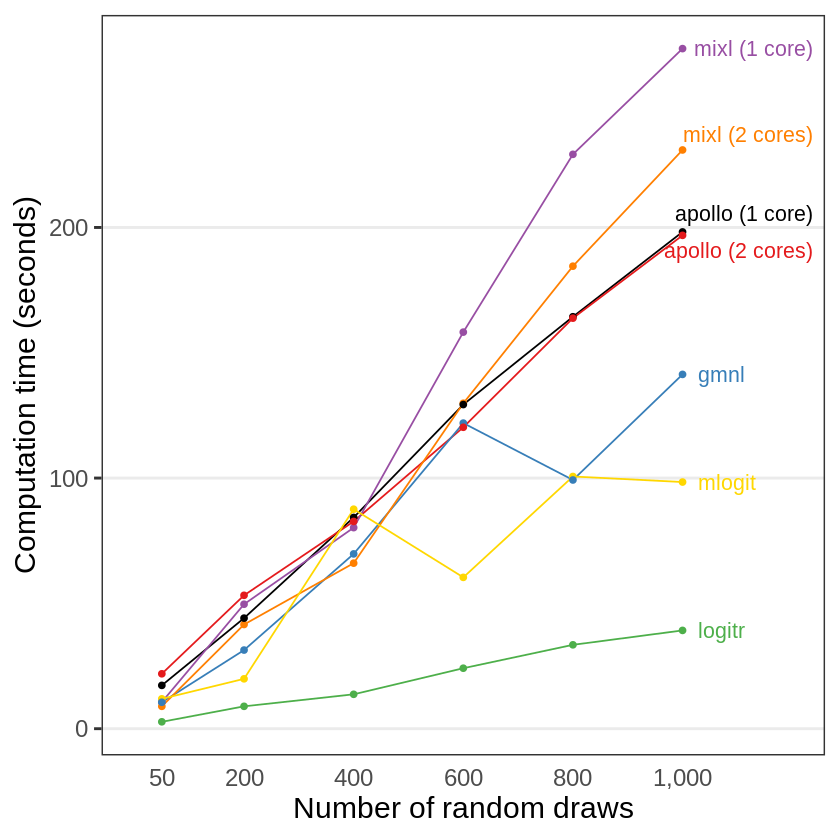

In [ ]:
# Make the figure
plotColors <- c("black", RColorBrewer::brewer.pal(n = 5, name = "Set1"), "gold")
runtimes %>%
    ggplot(aes(x = numDraws, y = time_sec, color = package)) +
    geom_line() +
    geom_point() +
    geom_text_repel(
        data = . %>% filter(numDraws == max(numDraws)),
        aes(label = package),
        hjust = 0, nudge_x = 40, direction = "y",
        size = 4.5, segment.size = 0
    ) +
    scale_x_continuous(
        limits = c(0, 1200),
        breaks = numDraws,
        labels = scales::comma) +
    # scale_y_continuous(limits = c(0, 300), breaks = seq(0, 300, 100)) +
    scale_color_manual(values = plotColors) +
    guides(
        point = guide_legend(override.aes = list(label = "")),
        color = guide_legend(override.aes = list(label = ""))) +
    theme_bw(base_size = 18) +
    theme(
        panel.grid.minor = element_blank(),
        panel.grid.major.x = element_blank(),
        legend.position = "none",
        axis.line.x = element_blank(),
        axis.ticks.x = element_blank()
    ) +
    labs(
        x = "Number of random draws",
        y = "Computation time (seconds)"
    )